<a href="https://colab.research.google.com/github/rijosudu123/ict-assessment/blob/main/Case_Study_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
import numpy as np
import pandas as pd
import os
import time
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler,MaxAbsScaler
from sklearn.model_selection import train_test_split

In [112]:
data = pd.read_csv("/content/Training_data.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


In [113]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [114]:
data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [115]:
data.duplicated().sum()

np.int64(0)

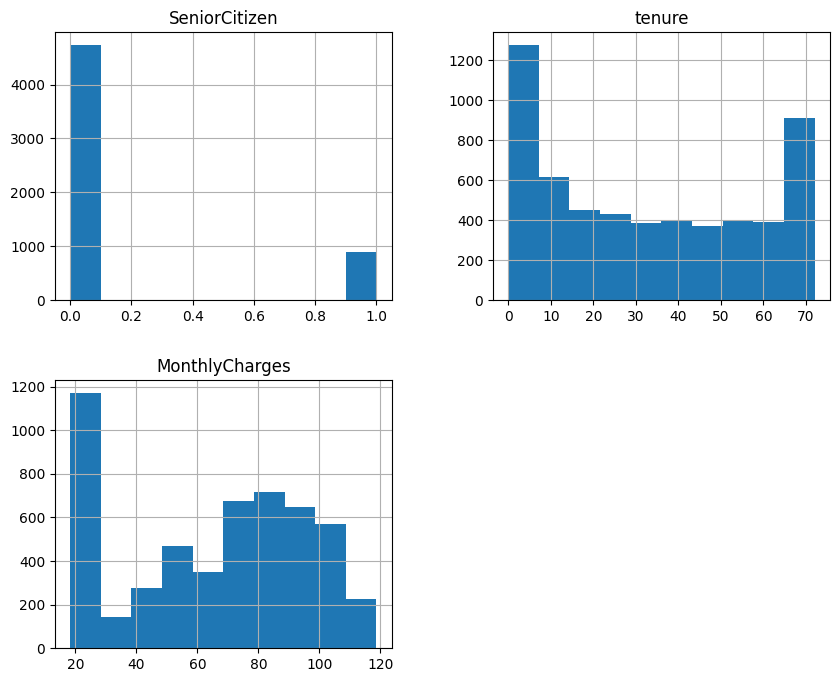

In [116]:
graph = data.select_dtypes(include = ['float64','int64'])
graph.hist(figsize=(10,8));


In [117]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce')

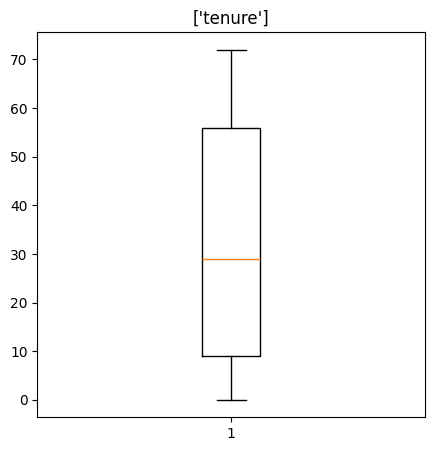

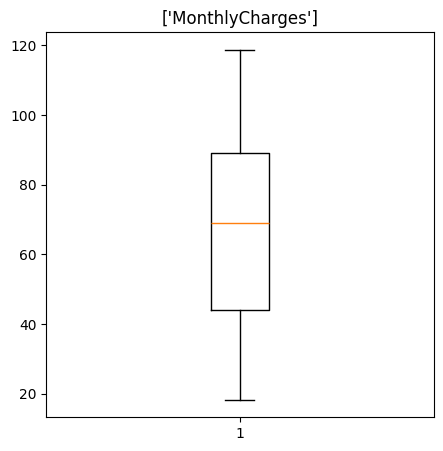

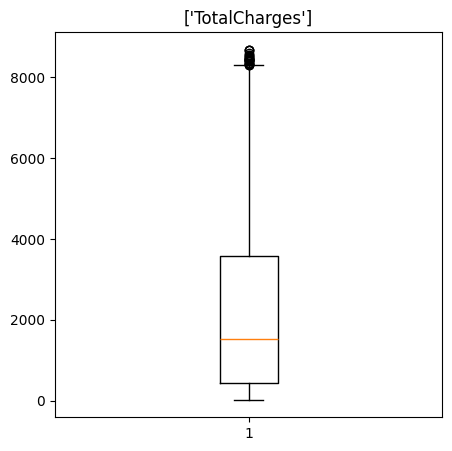

In [138]:
columns1 = ['tenure','MonthlyCharges','TotalCharges']
for col in columns1:
  plt.figure(figsize=(5,5))
  plt.boxplot(data[col])
  plt.title([col])

In [119]:
columns = ['MonthlyCharges','TotalCharges']
for i in columns:
  data[i] = data[i].fillna(data[i].mean())

In [120]:
columns = ['gender','OnlineSecurity']
for i in columns:
  data[i] = data[i].fillna(data[i].mode()[0])

In [121]:
data = data.drop(columns=['customerID'])

In [122]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,Male,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,Male,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,Female,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,0,No,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,Male,1,Yes,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,Female,0,No,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [123]:
label_enc = LabelEncoder()
data['Partner'] = label_enc.fit_transform(data['Partner'])
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,0,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,0,0,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,Male,0,0,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,Male,0,1,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,Female,0,1,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,0,0,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,Male,1,1,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,Male,0,1,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,Female,0,0,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [124]:
columns = ['Dependents','PhoneService','PaperlessBilling','Churn','gender']
for i in columns:
  data[i] = label_enc.fit_transform(data[i])

In [125]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,20.75,700.45,0
1,0,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,1,Mailed check,35.75,961.40,0
2,1,0,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,0,Electronic check,98.60,5581.05,0
3,1,0,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,790.00,0
4,0,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,1,Bank transfer (automatic),51.25,2151.60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,1,0,0,0,51,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.00,5038.15,0
5630,1,1,1,0,68,0,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,1,Electronic check,41.95,2965.75,0
5631,1,0,1,1,72,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),19.95,1322.85,0
5632,0,0,0,0,69,1,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),82.45,5555.30,0


In [126]:
data['MultipleLines'].value_counts()

,count
MultipleLines,
No,2701
Yes,2380
No phone service,553


In [127]:
ordinal_enc = OrdinalEncoder()
ordinal_enc = OrdinalEncoder(categories = [['No','No phone service','Yes']],dtype=int)
data['MultipleLines'] = ordinal_enc.fit_transform(data[['MultipleLines']])

In [128]:
ordinal_enc = OrdinalEncoder(categories = [['No','DSL','Fiber optic']],dtype=int)
data['InternetService'] = ordinal_enc.fit_transform(data[['InternetService']])

In [129]:
ordinal_enc = OrdinalEncoder(categories = [['One year','Month-to-month','Two year']],dtype=int)
data['Contract'] = ordinal_enc.fit_transform(data[['Contract']])

In [130]:
ordinal_enc = OrdinalEncoder(categories = [['Mailed check','Electronic check','Bank transfer (automatic)','Credit card (automatic)']],dtype=int)
data['PaymentMethod'] = ordinal_enc.fit_transform(data[['PaymentMethod']])

In [131]:
columns = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for i in columns:
  data[i] = label_enc.fit_transform(data[i])

In [132]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,0,1,1,1,1,1,1,0,0,0,20.75,700.45,0
1,0,0,0,0,28,0,1,1,0,0,2,2,0,0,1,1,0,35.75,961.40,0
2,1,0,0,0,56,1,2,2,0,2,0,0,2,2,1,0,1,98.60,5581.05,0
3,1,0,1,0,39,1,0,0,1,1,1,1,1,1,2,1,2,20.45,790.00,0
4,0,0,1,1,43,0,1,1,0,2,0,2,2,0,0,1,2,51.25,2151.60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,1,0,0,0,51,1,0,2,0,2,2,0,2,2,1,1,1,99.00,5038.15,0
5630,1,1,1,0,68,0,1,1,2,2,2,0,0,0,2,1,1,41.95,2965.75,0
5631,1,0,1,1,72,1,0,0,1,1,1,1,1,1,2,0,2,19.95,1322.85,0
5632,0,0,0,0,69,1,0,1,0,0,2,2,2,2,2,1,3,82.45,5555.30,0


In [133]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,0,1,1,1,1,1,1,0,0,0,20.75,700.45,0
1,0,0,0,0,28,0,1,1,0,0,2,2,0,0,1,1,0,35.75,961.40,0
2,1,0,0,0,56,1,2,2,0,2,0,0,2,2,1,0,1,98.60,5581.05,0
3,1,0,1,0,39,1,0,0,1,1,1,1,1,1,2,1,2,20.45,790.00,0
4,0,0,1,1,43,0,1,1,0,2,0,2,2,0,0,1,2,51.25,2151.60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,1,0,0,0,51,1,0,2,0,2,2,0,2,2,1,1,1,99.00,5038.15,0
5630,1,1,1,0,68,0,1,1,2,2,2,0,0,0,2,1,1,41.95,2965.75,0
5631,1,0,1,1,72,1,0,0,1,1,1,1,1,1,2,0,2,19.95,1322.85,0
5632,0,0,0,0,69,1,0,1,0,0,2,2,2,2,2,1,3,82.45,5555.30,0


In [145]:
q1=data["TotalCharges"].quantile(.25)
q3=data["TotalCharges"].quantile(.75)
iqr=q3-q1
lower=q1-iqr*1.5
upper=q3+iqr*1.5
print(f"\nq1:{q1},\nq3:{q3},\niqr:{iqr},\nlower:{lower},\nupper:{upper}")


q1:446.0625,
q3:3590.5375,
iqr:3144.475,
lower:-4270.65,
upper:8307.25


{'whiskers': [<matplotlib.lines.Line2D at 0x79abcc557650>,
 'caps': [<matplotlib.lines.Line2D at 0x79abcc554ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x79abcc556030>],
 'medians': [<matplotlib.lines.Line2D at 0x79abcf5c5460>],
 'fliers': [<matplotlib.lines.Line2D at 0x79abcf5c4530>],
 'means': []}

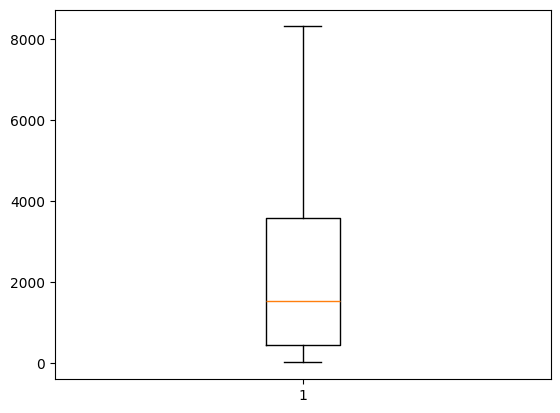

In [146]:
data['TotalCharges'] = data['TotalCharges'].clip(lower=lower,upper=upper)
plt.boxplot(data['TotalCharges'])

In [160]:
X = data.drop(columns=['Churn'])
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [161]:
scaler = StandardScaler()
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4082,1,0,1,1,0.709857,1,2,2,2,2,2,0,2,2,0,1,1,1.496561,1.446244
1728,1,1,0,0,-0.957030,1,0,1,0,0,0,2,0,0,1,0,0,-0.538916,-0.828926
2795,0,0,0,0,-1.200965,1,0,2,0,2,0,2,2,2,1,1,1,1.139793,-0.889464
334,1,0,0,0,0.140676,1,0,0,1,1,1,1,1,1,0,1,3,-1.533387,-0.715727
3625,0,1,0,0,-0.103259,0,1,1,0,0,2,0,2,0,1,1,1,-0.845703,-0.497912


In [168]:
from sklearn.metrics import accuracy_score


In [177]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight = 'balanced' )
lr_model.fit(X_train,y_train)
y_pred = lr_model.predict(X_test)

In [178]:
y_pred

array([0, 0, 0, ..., 1, 1, 0])

In [215]:
accuracy = accuracy_score(y_pred,y_test)
accuracy

0.7409050576752441

In [179]:
from sklearn.metrics import ConfusionMatrixDisplay

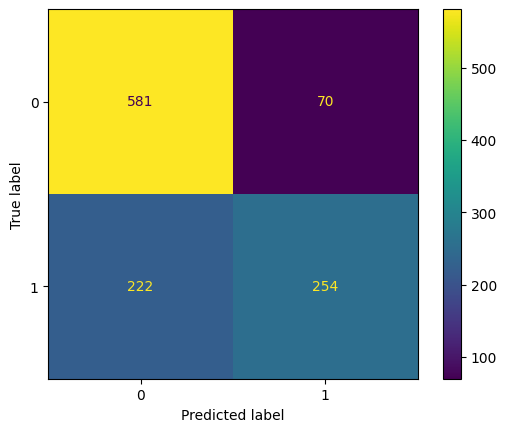

In [181]:
ConfusionMatrixDisplay.from_predictions(y_pred,y_test)

In [204]:
from sklearn.neighbors import KNeighborsClassifier

metrics_k = []

for i in np.arange(1,15):
  model_knn = KNeighborsClassifier(n_neighbors = i)
  model_knn.fit(X_train,y_train)
  y_pred_knn = model_knn.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred_knn)
  metrics_k.append(accuracy)
metrics_k

[0.7275953859804791,
 0.7453416149068323,
 0.7391304347826086,
 0.7577639751552795,
 0.7533274179236912,
 0.7559893522626442,
 0.7497781721384206,
 0.7497781721384206,
 0.7524401064773736,
 0.7524401064773736,
 0.7506654835847383,
 0.7630878438331854,
 0.7533274179236912,
 0.7648624667258208]

In [206]:
model_knn = KNeighborsClassifier(n_neighbors = 8)
model_knn.fit(X_train,y_train)
y_pred_knn = model_knn.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_knn)

In [208]:
accuracy = accuracy_score(y_test,y_pred_knn)
accuracy

0.7497781721384206

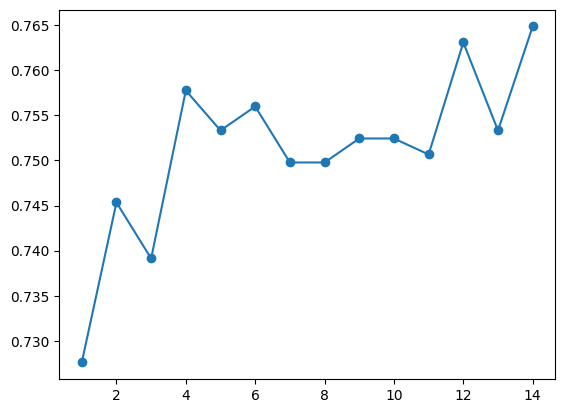

In [209]:
plt.plot(np.arange(1,15),metrics_k,marker='o')

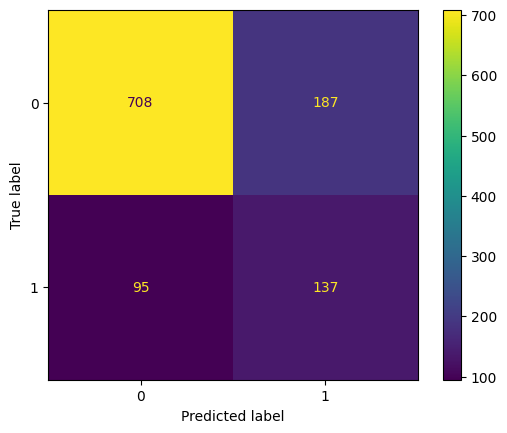

In [210]:
ConfusionMatrixDisplay.from_predictions(y_pred_knn,y_test)

In [223]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))

0.7790594498669032


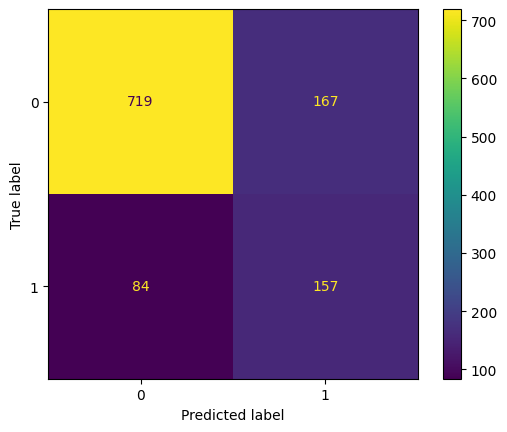

In [212]:
ConfusionMatrixDisplay.from_predictions(y_pred_rf,y_test)

In [213]:
model_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [224]:
from sklearn.model_selection import GridSearchCV

In [227]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12],
    'min_samples_leaf': [2, 4, 6],
    'criterion': ['gini', 'entropy'],
    'random_state': [42]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 100, 'random_state': 42}


In [229]:
best_model = rf_grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.7888198757763976


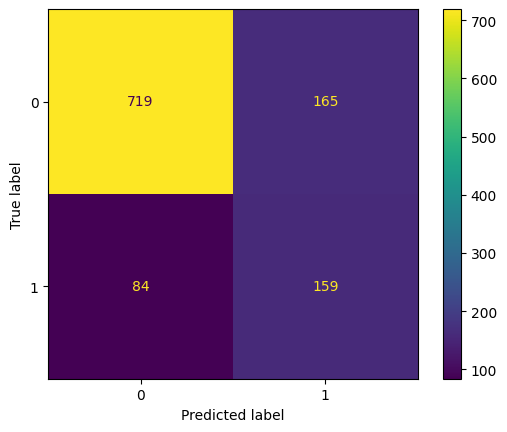

In [230]:
ConfusionMatrixDisplay.from_predictions(y_pred_rf,y_test)

#TESTING

In [231]:
test = pd.read_csv("/content/Testing_data.csv")
test

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,Male,0,No,No,27,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,2516-VQRRV,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.4,Yes
1406,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,1722-LDZJS,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


In [233]:
test = test.drop(columns=['customerID'])
test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,Male,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,Female,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,Male,0,No,No,27,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.4,Yes
1406,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,Male,0,Yes,Yes,53,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


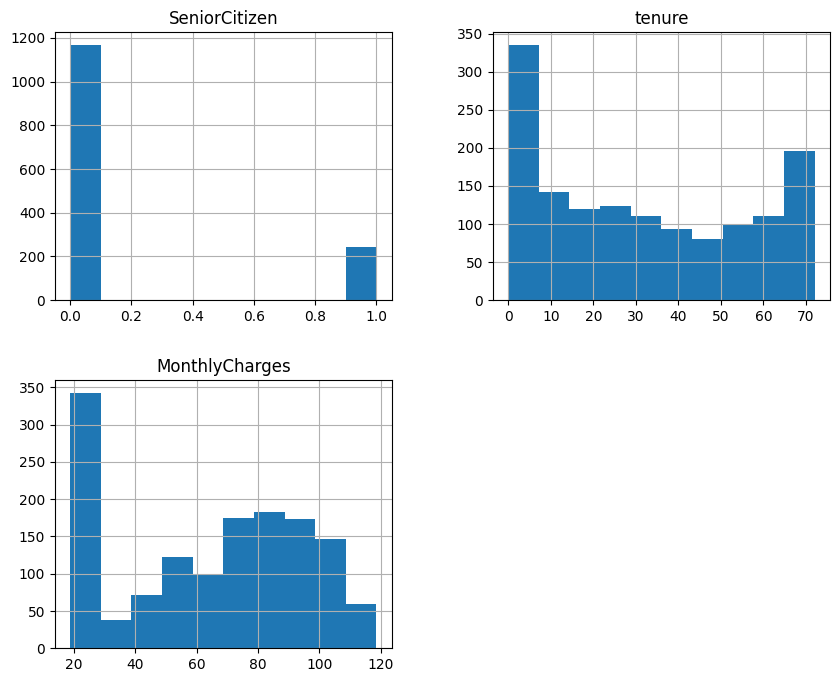

In [235]:
graph = test.select_dtypes(include = ['float64','int64'])
graph.hist(figsize=(10,8));

In [237]:
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'],errors='coerce')

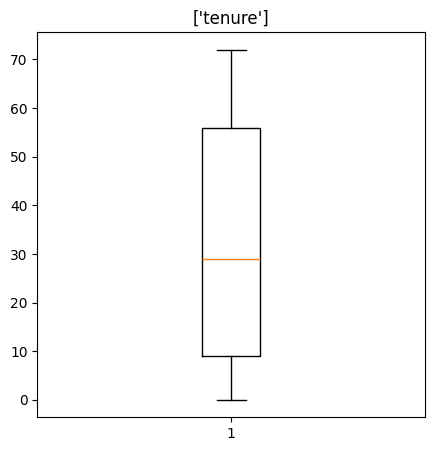

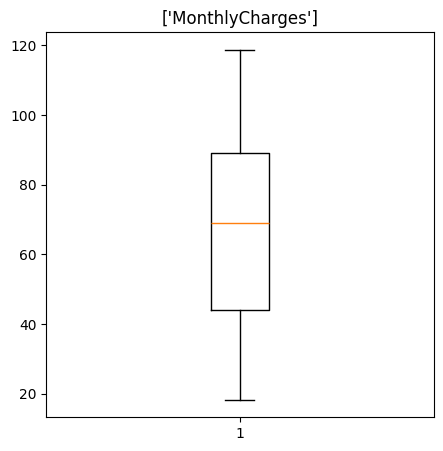

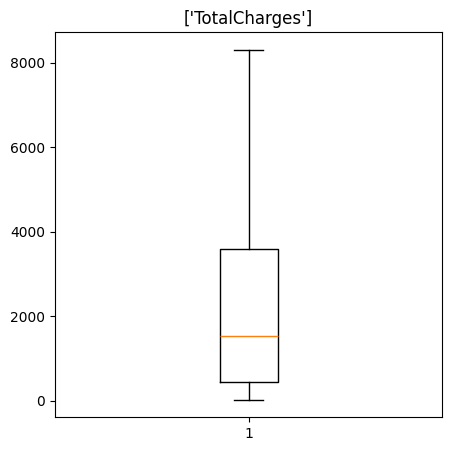

In [239]:
columns2 = ['tenure','MonthlyCharges','TotalCharges']
for col2 in columns2:
  plt.figure(figsize=(5,5))
  plt.boxplot(data[col2])
  plt.title([col2])

In [240]:
columns = ['MonthlyCharges','TotalCharges']
for i in columns:
  test[i] = test[i].fillna(test[i].mean())

In [241]:
columns = ['gender','OnlineSecurity']
for i in columns:
  test[i] = test[i].fillna(test[i].mode()[0])

In [242]:
label_enc = LabelEncoder()
test['Partner'] = label_enc.fit_transform(test['Partner'])
test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,1,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,Female,0,1,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,Male,0,0,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,Male,0,0,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,Female,0,0,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374.00,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,Male,0,0,No,27,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,Female,1,0,No,2,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.40,Yes
1406,Female,0,1,No,3,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,Male,0,1,Yes,53,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


In [245]:
test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,40,1,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,81.20,3292.30,0
1,0,0,1,0,12,1,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,0,Electronic check,78.85,876.75,0
2,1,0,0,0,43,1,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,1,Electronic check,100.00,4211.55,1
3,1,0,0,0,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Electronic check,118.20,8547.15,0
4,0,0,0,0,10,0,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,0,Electronic check,36.25,374.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,1,0,0,0,27,1,No,DSL,Yes,Yes,No,No,No,No,One year,0,Bank transfer (automatic),55.45,1477.65,0
1405,0,1,0,0,2,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,75.45,158.40,1
1406,0,0,1,0,3,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Credit card (automatic),75.15,216.75,1
1407,1,0,1,1,53,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Credit card (automatic),20.20,1068.15,0


In [244]:
columns = ['Dependents','PhoneService','PaperlessBilling','Churn','gender']
for i in columns:
  test[i] = label_enc.fit_transform(test[i])

In [247]:
ordinal_enc1 = OrdinalEncoder()
ordinal_enc1 = OrdinalEncoder(categories = [['No','No phone service','Yes']],dtype=int)
test['MultipleLines'] = ordinal_enc1.fit_transform(test[['MultipleLines']])

In [248]:
ordinal_enc = OrdinalEncoder(categories = [['No','DSL','Fiber optic']],dtype=int)
test['InternetService'] = ordinal_enc.fit_transform(test[['InternetService']])

In [249]:
ordinal_enc = OrdinalEncoder(categories = [['One year','Month-to-month','Two year']],dtype=int)
test['Contract'] = ordinal_enc.fit_transform(test[['Contract']])

In [250]:
ordinal_enc = OrdinalEncoder(categories = [['Mailed check','Electronic check','Bank transfer (automatic)','Credit card (automatic)']],dtype=int)
test['PaymentMethod'] = ordinal_enc.fit_transform(test[['PaymentMethod']])

In [251]:
columns = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for i in columns:
  test[i] = label_enc.fit_transform(test[i])

In [254]:
X = test.drop(columns=['Churn'])
y = test['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [255]:
scaler = StandardScaler()
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1034,0,0,1,0,-0.071693,1,2,2,0,0,0,0,0,2,1,1,1,0.688215,0.166131
579,1,0,1,1,-0.607324,1,2,1,2,0,0,2,0,0,0,1,0,-0.067566,-0.510747
1138,1,0,1,1,1.617606,1,2,0,1,1,1,1,1,1,2,0,3,-1.280446,-0.178024
48,0,0,0,0,-0.277705,1,0,0,1,1,1,1,1,1,0,0,3,-1.460316,-0.762937
155,0,0,1,1,1.329190,1,0,0,1,1,1,1,1,1,0,0,2,-1.463616,-0.404403


In [256]:
from sklearn.metrics import accuracy_score


In [257]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight = 'balanced' )
lr_model.fit(X_train,y_train)
y_pred = lr_model.predict(X_test)

In [258]:
y_pred

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1])

In [259]:
accuracy = accuracy_score(y_pred,y_test)
accuracy

0.7056737588652482

In [260]:
from sklearn.metrics import ConfusionMatrixDisplay

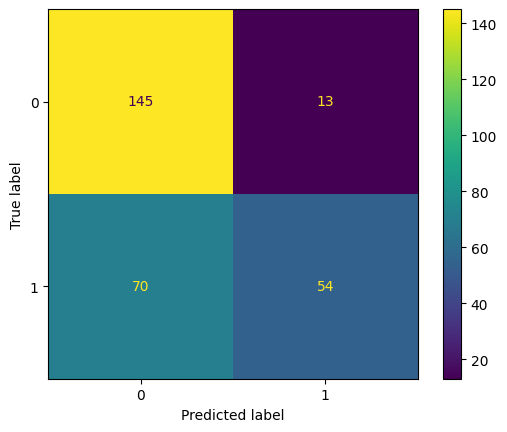

In [261]:
ConfusionMatrixDisplay.from_predictions(y_pred,y_test)

In [262]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))

0.8120567375886525


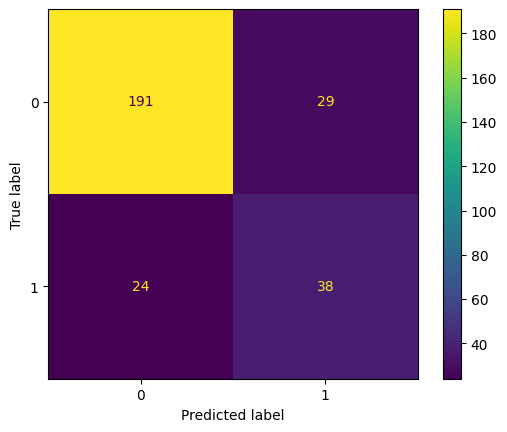

In [263]:
ConfusionMatrixDisplay.from_predictions(y_pred_rf,y_test)